# Exploratory Data Analysis (EDA)

This section is where we start asking questions of the cleaned bestiary data. 

The main question we want to answer is:

> *Which monster attributes really move with Challenge Rating (CR), and which ones are just noise?*

To answer that, We’ll:
- look at individual distributions (HP, AC, CR, ability scores)
- compare categories (Size, Type) to see where the outliers live
- check correlations and variance so we know what the model should pay attention to

---

### Project setup

- **Dataset:** `../data/prepared_bestiary.csv` (cleaned version of the raw bestiary)
- **Goal:** Find the strongest signals for Challenge Rating so we can build better features later.

---

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('fivethirtyeight')
sns.set_theme(style="whitegrid")

# Load prepared dataset
prepared_df = pd.read_csv('../data/prepared_bestiary.csv')

# Print dataset info
print("--- Dataset Information ---")
prepared_df.info()

# Display summary statistics
print("\n--- Statistical Summary ---")
display(prepared_df.describe())

# Display first 5 records
print("\n--- First 5 Records ---")
display(prepared_df.head())

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 3658 entries, 0 to 3657
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    3658 non-null   str    
 1   Source                  3658 non-null   str    
 2   Page                    3658 non-null   str    
 3   Size                    3658 non-null   str    
 4   Type                    3658 non-null   str    
 5   Alignment               3658 non-null   str    
 6   AC                      3658 non-null   int64  
 7   HP                      3658 non-null   int64  
 8   Speed                   3658 non-null   str    
 9   Strength                3658 non-null   int64  
 10  Dexterity               3658 non-null   int64  
 11  Constitution            3658 non-null   int64  
 12  Intelligence            3658 non-null   int64  
 13  Wisdom                  3658 non-null   int64  
 14  Charisma               

,AC,HP,Strength,Dexterity,Constitution,Intelligence,Wisdom,Charisma,CR
count,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000
mean,14.685894,96.116184,15.120831,13.423455,15.318480,10.694369,12.800164,11.664297,5.986844
std,2.965027,99.855364,6.004524,3.339387,4.186191,5.678043,3.550985,5.646058,6.189269
min,5.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,0.000000
25%,12.000000,27.000000,11.000000,11.000000,12.000000,6.000000,10.000000,7.000000,1.000000
50%,15.000000,66.000000,15.000000,14.000000,14.000000,11.000000,12.000000,11.000000,4.000000
75%,17.000000,135.000000,19.000000,15.000000,18.000000,14.000000,15.000000,16.000000,9.000000
max,25.000000,725.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000



--- First 5 Records ---


,Name,Source,Page,Size,Type,Alignment,AC,HP,Speed,Strength,...,Bonus Actions,Reactions,Legendary Actions,Mythic Actions,Lair Actions,Regional Effects,Environment,Treasure,HP_Formula,Subtype
0,the demogorgon,imr,53,large,giant,chaotic neutral,15,123,40 ft.,21,...,none,none,none,none,none,none,unknown,none,13d12 + 39,none
1,aarakocra,mm14,12,medium,humanoid,neutral good,12,13,"20 ft., fly 50 ft.",10,...,none,none,none,none,none,none,mountain,none,3d8,aarakocra
2,aarakocra aeromancer,mm25,10,medium,elemental,neutral,16,66,"20 ft., fly 50 ft.",10,...,none,feather fall (1/day). the aarakocra casts feat...,none,none,none,none,"mountain, planar (elemental plane of air)","individual, implements",12d8 + 12,none
3,aarakocra simulacrum,skt,188,medium,humanoid,neutral good,12,6,"20 ft., fly 50 ft.",10,...,none,none,none,none,none,none,unknown,none,3d4,aarakocra
4,aarakocra skirmisher,mm25,10,medium,elemental,neutral,12,11,"20 ft., fly 50 ft.",10,...,none,none,none,none,none,none,"mountain, planar (elemental plane of air)","individual, implements",2d8 + 2,none


## Univariate Analysis (Individual Distributions)
Before building any models, it helps to look at one variable at a time. Here we'll explore the shape of the distributions, spot obvious outliers, and check whether any features are too narrow (which makes them less useful for modeling).

### 1.1 Numerical Histograms
We plot histograms to determine if numeric features are normally distributed or skewed.

* **Target Variable:** `CR` (Challenge Rating) 
    - This is expected to have a heavy skew toward lower values due to how DnD works.
* **Defensive Stats:** `AC` (Armor Class) and `HP`.
* **Attributes:** The six Core Ability Scores (`STR`, `DEX`, `CON`, `INT`, `WIS`, `CHA`).

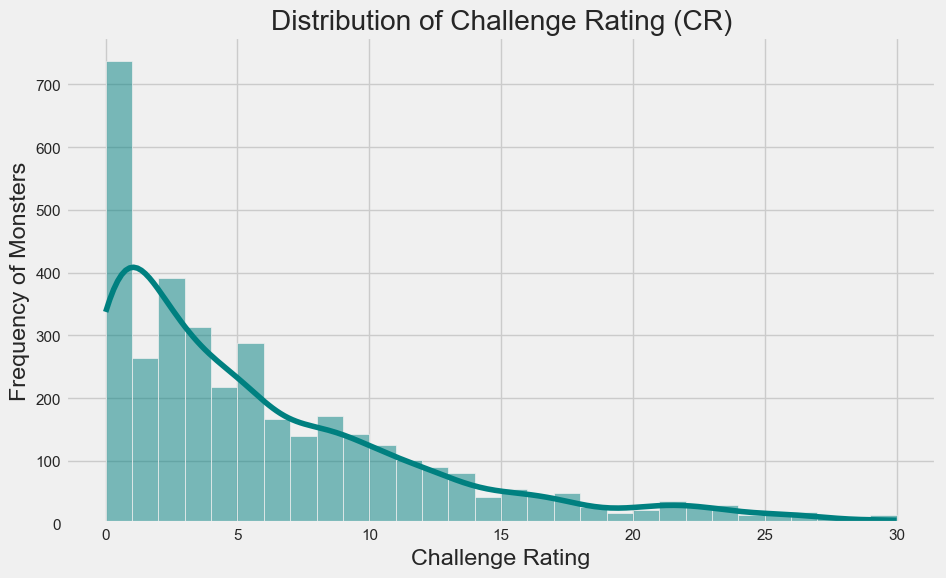

count    3658.000000
mean        5.986844
std         6.189269
min         0.000000
25%         1.000000
50%         4.000000
75%         9.000000
max        30.000000
Name: CR, dtype: float64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
plt.style.use('fivethirtyeight')

# Plotting the distribution of CR
plt.figure(figsize=(10, 6))
sns.histplot(prepared_df['CR'], bins=30, kde=True, color='teal')

# Customizing the labels
plt.title('Distribution of Challenge Rating (CR)')
plt.xlabel('Challenge Rating')
plt.ylabel('Frequency of Monsters')

# Save the visualization for the poster
plt.savefig('../diagrams/cr_distribution.png')
plt.show()

# Display summary statistics
print(prepared_df['CR'].describe())

This distribution shows that our dataset is quite bottom-heavy, meaning most monsters are weak while very few are powerful. 

- The average Challenge Rating is around 6, but the median is actually 4, which confirms that a large cluster of monsters sits between CR 0 and CR 5. 
- The standard deviation of 6.18 is quite high relative to the mean, indicating a wide spread in power levels across the rest of the list.

Because the data is so skewed, our model will have plenty of examples of weak monsters to learn from, but it might struggle to predict high CR values accurately unless we specifically account for those sparse data points at the top end. 

TODO: expound on this + point out what we do in here in the latter half of the nb

                AC           HP
count  3658.000000  3658.000000
mean     14.685894    96.116184
std       2.965027    99.855364
min       5.000000     1.000000
25%      12.000000    27.000000
50%      15.000000    66.000000
75%      17.000000   135.000000
max      25.000000   725.000000


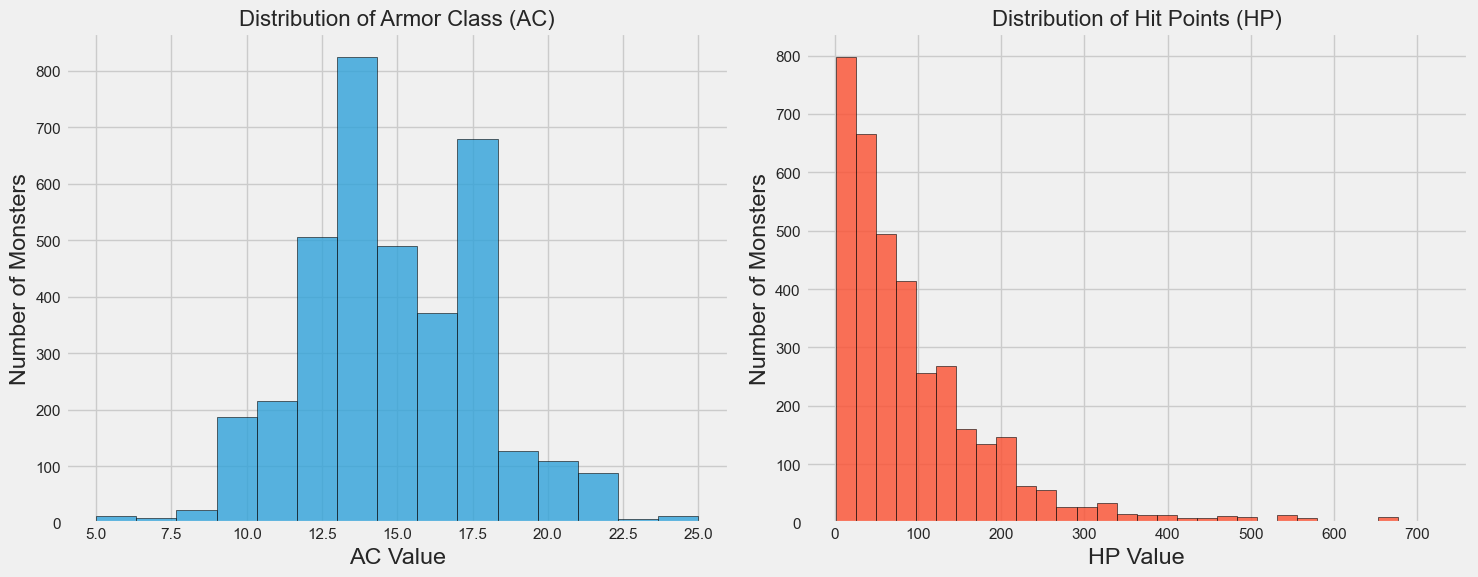

In [4]:
# Set visual style
plt.style.use('fivethirtyeight')

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot AC distribution
ax1.hist(prepared_df['AC'], bins=15, color='#30a2da', edgecolor='black', alpha=0.8)
ax1.set_title('Distribution of Armor Class (AC)', fontsize=16)
ax1.set_xlabel('AC Value')
ax1.set_ylabel('Number of Monsters')

# Plot HP distribution
ax2.hist(prepared_df['HP'], bins=30, color='#fc4f30', edgecolor='black', alpha=0.8)
ax2.set_title('Distribution of Hit Points (HP)', fontsize=16)
ax2.set_xlabel('HP Value')
ax2.set_ylabel('Number of Monsters')

# Save plot
plt.tight_layout()
plt.savefig('../diagrams/defensive_stats_distribution.png')

# Print summary statistics
print(prepared_df[['AC', 'HP']].describe())

Armor Class behaves like a tightly controlled stat, while Hit Points are all over the place.

In this dataset:
* **AC** sits mostly between 12 and 17, and even the strongest creatures rarely go above 25. 
    - a single point of AC can make a big difference in a model’s eyes.
* **HP**, on the other hand, ranges from a handful to over 700. 
    - There are a few “HP sponges” that push the average way up, which makes the distribution look like a fat tail.

* TODO: look more into this

If we train a model directly on raw numbers, it will probably lean heavily on HP because it varies so much more than AC.

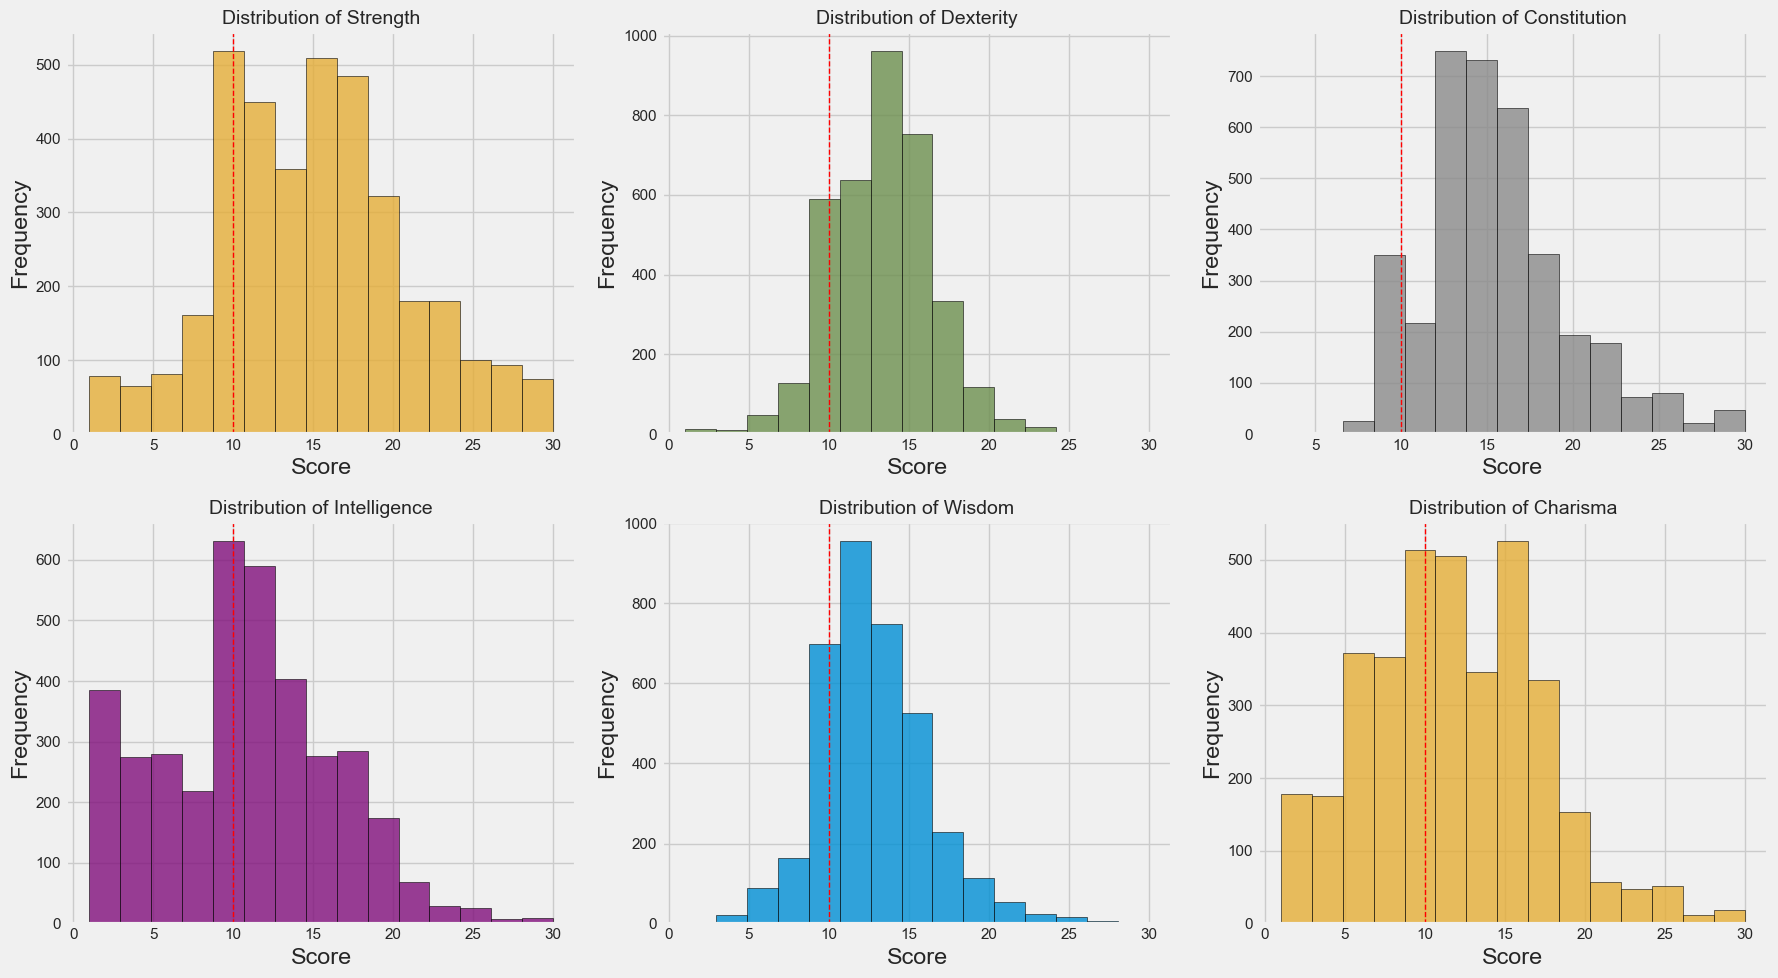

          Strength    Dexterity  Constitution  Intelligence       Wisdom  \
count  3658.000000  3658.000000   3658.000000   3658.000000  3658.000000   
mean     15.120831    13.423455     15.318480     10.694369    12.800164   
std       6.004524     3.339387      4.186191      5.678043     3.550985   
min       1.000000     1.000000      3.000000      1.000000     1.000000   
25%      11.000000    11.000000     12.000000      6.000000    10.000000   
50%      15.000000    14.000000     14.000000     11.000000    12.000000   
75%      19.000000    15.000000     18.000000     14.000000    15.000000   
max      30.000000    30.000000     30.000000     30.000000    30.000000   

          Charisma  
count  3658.000000  
mean     11.664297  
std       5.646058  
min       1.000000  
25%       7.000000  
50%      11.000000  
75%      16.000000  
max      30.000000  


In [5]:
import matplotlib.pyplot as plt

# Define the attributes to plot
attributes = ['Strength', 'Dexterity', 'Constitution', 'Intelligence', 'Wisdom', 'Charisma']
colors = ['#e5ae38', '#6d904f', '#8b8b8b', '#810f7c', '#008fd5', '#e5ae37']

# Set the visual style
plt.style.use('fivethirtyeight')

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(attributes):
    axes[i].hist(prepared_df[col], bins=15, color=colors[i], edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Frequency')
    # Draw a vertical line at 10 (Human Average)
    axes[i].axvline(10, color='red', linestyle='--', linewidth=1, label='Human Avg (10)')

plt.tight_layout()

# Save the plot for the poster
plt.savefig('../diagrams/attributes_distribution.png')
plt.show()

# Display summary statistics for the attributes
print(prepared_df[attributes].describe())

The ability scores show a familiar pattern: **physical traits are “tougher” than mental traits.** TODO: what does this even mean lol

Most monsters are stronger and tougher than a human (the red line at 10), while their Intelligence and Charisma tend to cluster closer to human norms. Strength has the widest range whereas Wisdom and Dexterity stay fairly narrow.

That matters for modeling because features that vary more are often more informative. Strength and Constitution stretch the most, so they’re likely to be better predictors of CR than, say, Dexterity.

TODO: go over this again

### 1.2 Categorical Counts
Now let’s look at the categorical features that give monsters their “identity”.

* **Size:** Tiny → Gargantuan tells us how big the creature is.
* **Type:** Things like Undead, Dragon, Fiend  
    - these categories often come with built-in expectations about power and behavior.

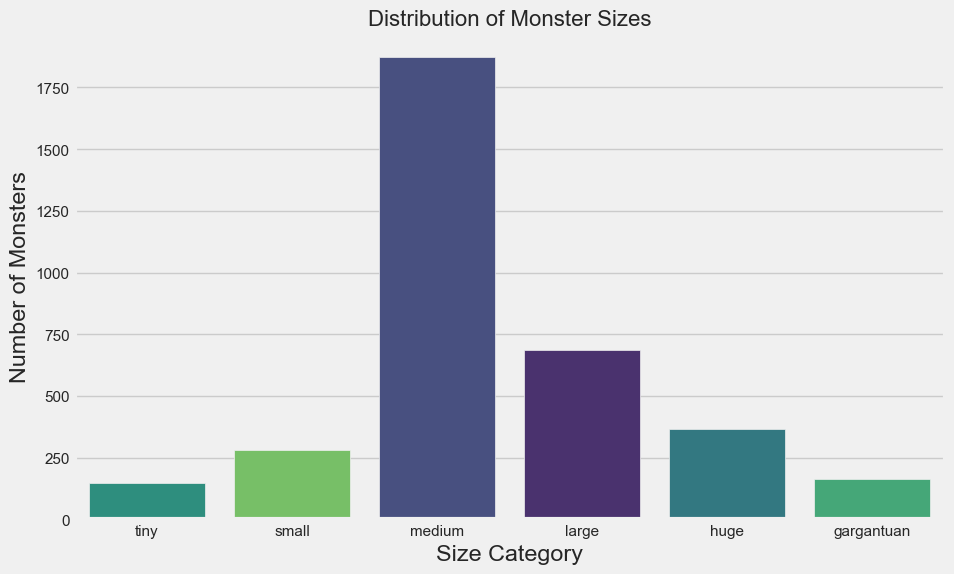

Size
tiny           146
small          281
medium        1875
large          688
huge           365
gargantuan     164
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt

# Set visual style
plt.style.use('fivethirtyeight')

# Define size order
size_order_lower = ['tiny', 'small', 'medium', 'large', 'huge', 'gargantuan']

# Plot distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=prepared_df, x='Size', order=size_order_lower, palette='viridis', hue='Size', legend=False)

# Set labels
plt.title('Distribution of Monster Sizes', fontsize=16)
plt.xlabel('Size Category')
plt.ylabel('Number of Monsters')
plt.show()

# Print counts
print(prepared_df['Size'].value_counts().reindex(size_order_lower))

Medium is the dominant standard for monster design, accounting for more than half of the entire bestiary.

This distribution shows that the "Medium" category is the baseline for D&D encounters, likely because most player characters are also medium-sized. 

As monsters get larger or smaller than this midpoint, their frequency drops off significantly. 

> Interestingly, there are more "Gargantuan" monsters than "Tiny" ones, suggesting the game provides more high-scale bosses than it does microscopic threats.

From a modeling perspective,
- The "Medium" category is our most reliable data point, but the "Large" and "Huge" categories still have enough samples to be statistically significant. 
- The extremes (Tiny and Gargantuan) are relatively rare. This means our model might become very good at predicting the CR of human-sized enemies but will have much less "experience" with the outliers at either end of the size spectrum.

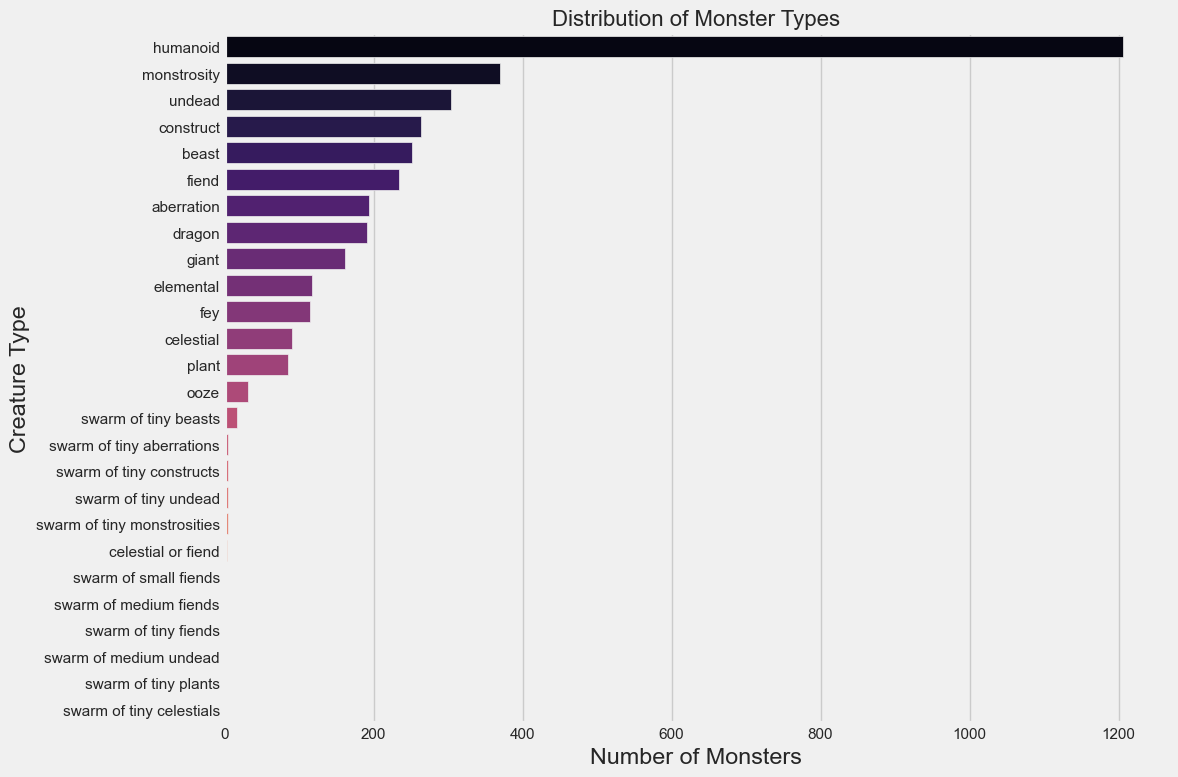

Type
humanoid                       1206
monstrosity                     369
undead                          304
construct                       264
beast                           252
fiend                           234
aberration                      194
dragon                          191
giant                           161
elemental                       117
fey                             115
celestial                        91
plant                            85
ooze                             32
swarm of tiny beasts             16
swarm of tiny aberrations         4
swarm of tiny constructs          4
swarm of tiny undead              4
swarm of tiny monstrosities       4
celestial or fiend                3
swarm of small fiends             2
swarm of medium fiends            2
swarm of tiny fiends              1
swarm of medium undead            1
swarm of tiny plants              1
swarm of tiny celestials          1
Name: count, dtype: int64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
plt.style.use('fivethirtyeight')

# Calculate type frequency
type_counts = prepared_df['Type'].value_counts()

# Plot distribution
plt.figure(figsize=(12, 8))
sns.barplot(x=type_counts.values, y=type_counts.index, hue=type_counts.index, palette='magma', legend=False)

# Set labels
plt.title('Distribution of Monster Types', fontsize=16)
plt.xlabel('Number of Monsters')
plt.ylabel('Creature Type')

# Save plot
plt.tight_layout()
plt.savefig('../diagrams/type_distribution.png')
plt.show()

# Print counts
print(type_counts)

Monster types are wildly unbalanced: one type dominates, and many others barely show up.

*Humanoids* are the biggest group by far (more than **three times the next type!!** ) which makes sense given how much D&D focuses on people and city encounters. 
- This means the model will get plenty of practice learning what makes a humanoid tick, but it might struggle with rare creatures like *Ooze* or *Plant* simply because there aren’t many examples.


On the flip side, the dataset has a long tail of low-frequency types (like swarms or merged types). Those are effectively “noise” for a machine learning model unless  we to group them into broader buckets (e.g., collapse “Swarm of X” into a single “Swarm” category). TODO: look into if we did this

### 1.3 Outlier Detection & Variance Check
Now that we’ve seen the distributions, let’s look for the weird ones.

* **Boxplots:** Great for spotting major outliers in HP and AC.
* **Variance check:** If a feature barely changes (e.g., 95% of monsters have the same value), it won’t help a model learn much. TODO: add an explanation for this 

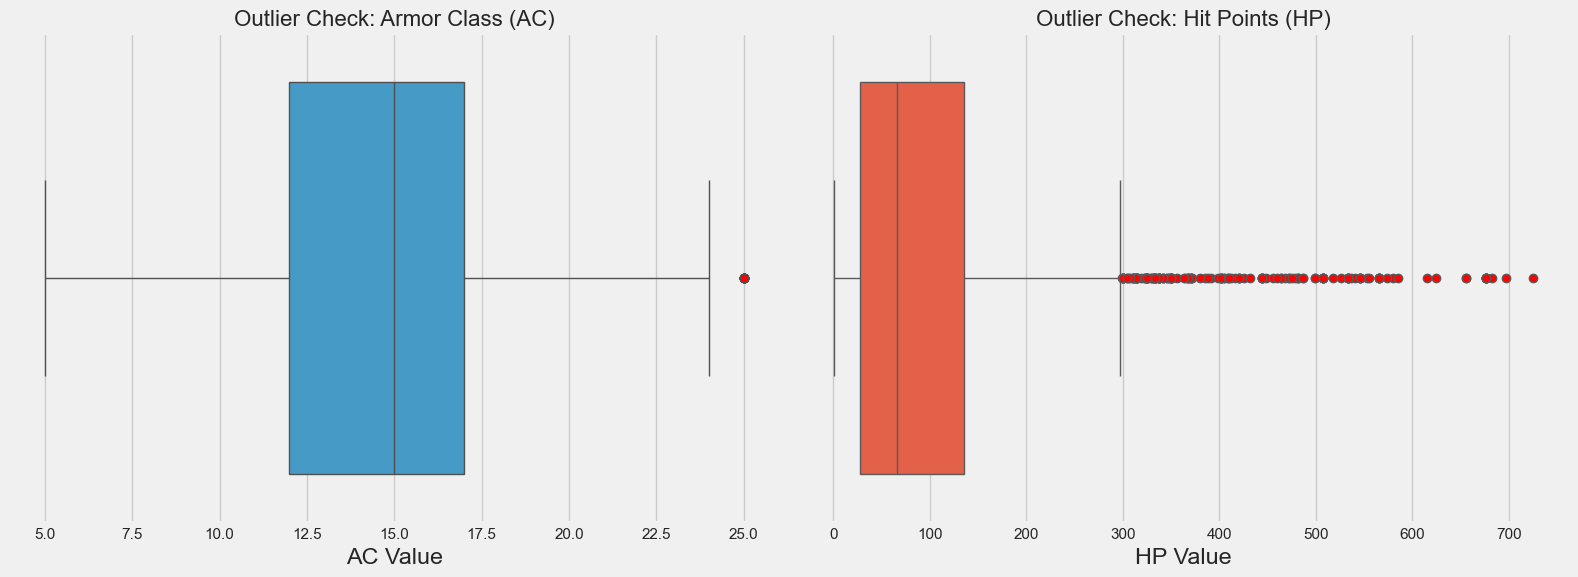

--- Top 5 HP Outliers ---


,Name,CR,HP
240,asmodeus,30.0,725
3089,tarrasque,30.0,697
670,cradle of the storm scion,27.0,682
986,elder dinosaur,30.0,676
987,"elder dinosaur (etali, primal storm)",30.0,676



--- Top 5 AC Outliers ---


,Name,CR,AC
986,elder dinosaur,30.0,25
987,"elder dinosaur (etali, primal storm)",30.0,25
988,"elder dinosaur (ghalta, primal hunger)",30.0,25
989,"elder dinosaur (nezahal, primal tide)",30.0,25
990,"elder dinosaur (tetzimoc, primal death)",30.0,25


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
plt.style.use('fivethirtyeight')

# Setup subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot AC boxplot
sns.boxplot(x=prepared_df['AC'], ax=ax1, color='#30a2da', flierprops={'markerfacecolor':'red', 'marker':'o'})
ax1.set_title('Outlier Check: Armor Class (AC)', fontsize=16)
ax1.set_xlabel('AC Value')

# Plot HP boxplot
sns.boxplot(x=prepared_df['HP'], ax=ax2, color='#fc4f30', flierprops={'markerfacecolor':'red', 'marker':'o'})
ax2.set_title('Outlier Check: Hit Points (HP)', fontsize=16)
ax2.set_xlabel('HP Value')

plt.tight_layout()
plt.show()

# Print statistical outliers
print("--- Top 5 HP Outliers ---")
display(prepared_df.nlargest(5, 'HP')[['Name', 'CR', 'HP']])

print("\n--- Top 5 AC Outliers ---")
display(prepared_df.nlargest(5, 'AC')[['Name', 'CR', 'AC']])

This data shows how D&D monster stats are designed with specific limits. Armor Class is a bounded stat. Most monsters have an AC between 12 and 18. Even the most powerful legendary creatures rarely go above 25. This means our model only needs to look at a small range of numbers to understand a monster's defense. Because the range is so small, every single point of AC matters a lot for the final Challenge Rating.

Hit Points are unbounded and scale differently. While most monsters stay under 100 HP, the top tier bosses jump to over 600 or 700. This creates a very long tail in our data. The gap between a normal monster and a boss is massive in terms of health but small in terms of AC. This tells the model that HP is the primary way the game scales difficulty at higher levels.

The top 5 lists prove this pattern. All of the strongest monsters hit the same ceiling of 25 for AC, but their HP totals vary by much larger amounts. When you build our model, it will likely rely on HP to distinguish between different high level monsters since their AC values will all look very similar.

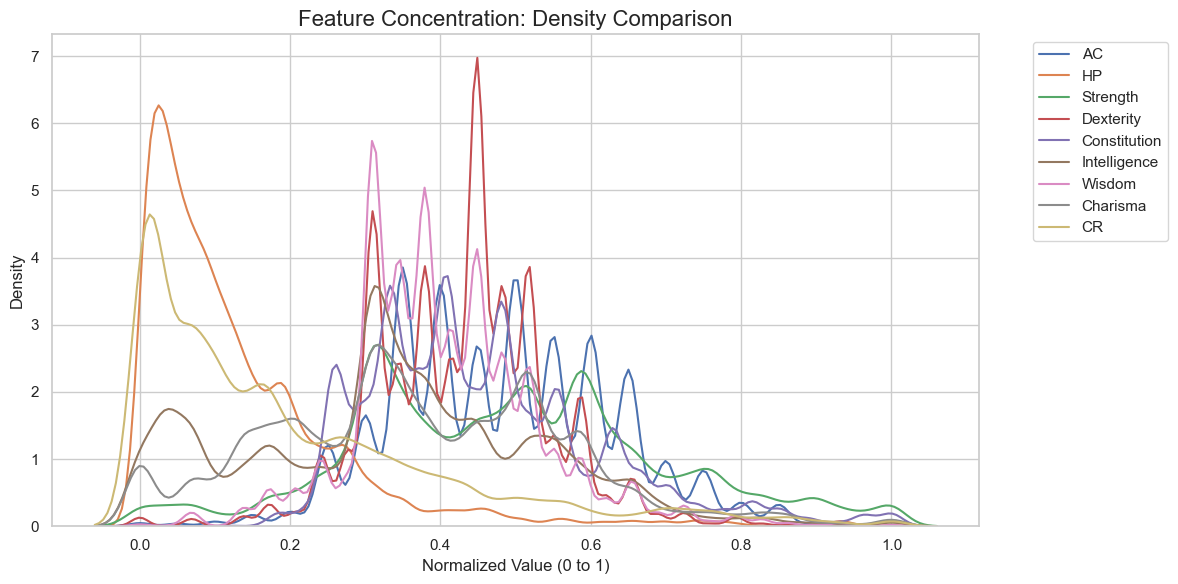


--- Numeric Features Identified ---
['AC', 'HP', 'Strength', 'Dexterity', 'Constitution', 'Intelligence', 'Wisdom', 'Charisma', 'CR']


In [9]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('fivethirtyeight')
sns.set_theme(style="whitegrid")

# Identify numeric features
numeric_features = prepared_df.select_dtypes(include=[np.number]).columns.tolist()

# Normalize data 
normalized_df = (prepared_df[numeric_features] - prepared_df[numeric_features].min()) / \
                (prepared_df[numeric_features].max() - prepared_df[numeric_features].min() + 1e-9)

# Create KDE plot
plt.figure(figsize=(12, 6))
for col in numeric_features:
    sns.kdeplot(data=normalized_df[col], label=col, bw_adjust=0.5)

# Set labels and legend
plt.title('Feature Concentration: Density Comparison', fontsize=16)
plt.xlabel('Normalized Value (0 to 1)')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()

# Print feature list
print("\n--- Numeric Features Identified ---")
print(numeric_features)

This density plot shows which monster stats are predictable and which are varied. Stats with a high, thin peak have low variance. This means most monsters share nearly the same value for that trait. Stats with a flat, wide curve have high variance, meaning the values are spread out across the bestiary.

Dexterity, Wisdom, and Armor Class show the sharpest peaks. This indicates these stats stay very consistent regardless of how powerful a monster is. Most creatures in the game cluster around the same average for these three traits. Because they do not change much, they may have less influence on the final Challenge Rating.

Strength and Hit Points show much flatter curves. These stats are spread across the entire range from zero to one. This variety suggests that as monsters get stronger, these are the primary numbers that designers change. These high-variance features are likely the most important signals for our model to use when predicting a monster's power level.

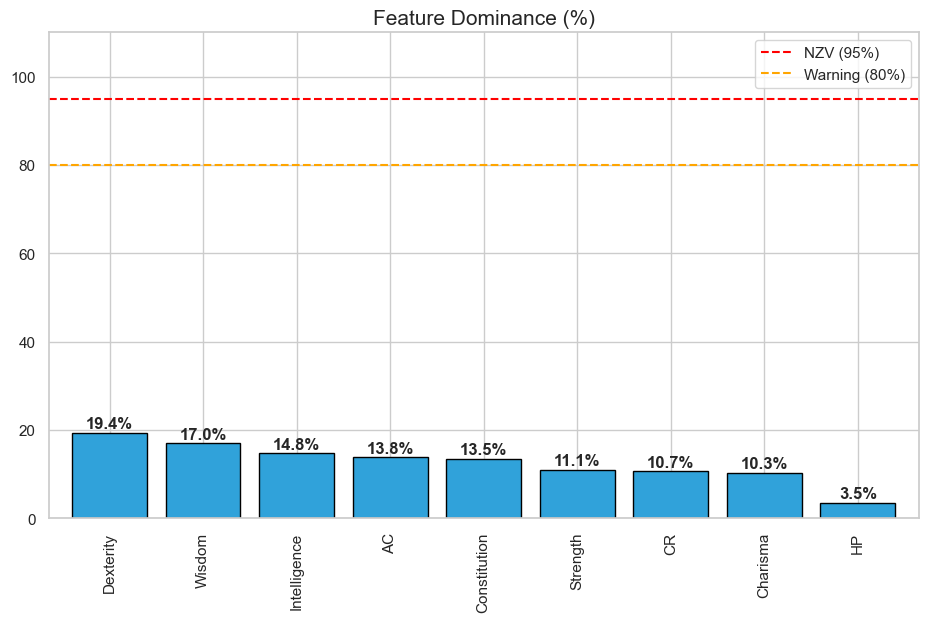

Dexterity       19.41
Wisdom          17.03
Intelligence    14.79
AC              13.83
Constitution    13.48
Strength        11.07
CR              10.72
Charisma        10.33
HP               3.53
dtype: float64


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Setup dominance data
cols = ['AC', 'HP', 'Strength', 'Dexterity', 'Constitution', 'Intelligence', 'Wisdom', 'Charisma', 'CR']
dom = pd.Series({c: prepared_df[c].value_counts(normalize=True).max() * 100 for c in cols}).sort_values(ascending=False)

# Plot feature dominance
plt.figure(figsize=(10, 6))
colors = ['#fc4f30' if x > 80 else '#30a2da' for x in dom]
ax = dom.plot(kind='bar', color=colors, edgecolor='black', width=0.8)

# Add value labels and threshold lines
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height() + 1), ha='center', fontweight='bold')

plt.axhline(95, color='red', ls='--', label='NZV (95%)')
plt.axhline(80, color='orange', ls='--', label='Warning (80%)')
plt.title('Feature Dominance (%)', fontsize=15)
plt.ylim(0, 110)
plt.legend()
plt.show()

# Print raw values
print(dom.round(2))

This chart confirms that our data is incredibly diverse and healthy for machine learning.

Dexterity and Wisdom are our most "repetitive" stats, but even they only have a common value about 19% of the time. This means that for 80% of the monsters in our list, these stats are varied and unique. Since no bar comes close to the 80% or 95% lines, We do not have a problem with near-zero variance. Every stat we have chosen offers unique information that the model can use to distinguish one monster from another.

Hit Points (HP) has the lowest dominance at only 3.5%. This is the best possible result for a predictive model. It means almost every monster has a specific, unique health total. This lack of repetition creates a very smooth gradient of data points, which helps a model find the exact mathematical "tipping point" where a monster moves from one Challenge Rating to the next.

## Phase 2: Bivariate Analysis (Direct Correlations)
**Goal:** Identify which specific numerical attributes move in sync with the Challenge Rating.

### 2.1 Correlation Heatmap
We generate a heatmap to calculate the correlation coefficients between `HP`, `AC`, `STR`, `DEX`, `CON`, `INT`, `WIS`, `CHA`, and `CR`. 
* **Action:** We prioritize features with high coefficients ($> 0.7$) as they likely represent the strongest predictors for the model.

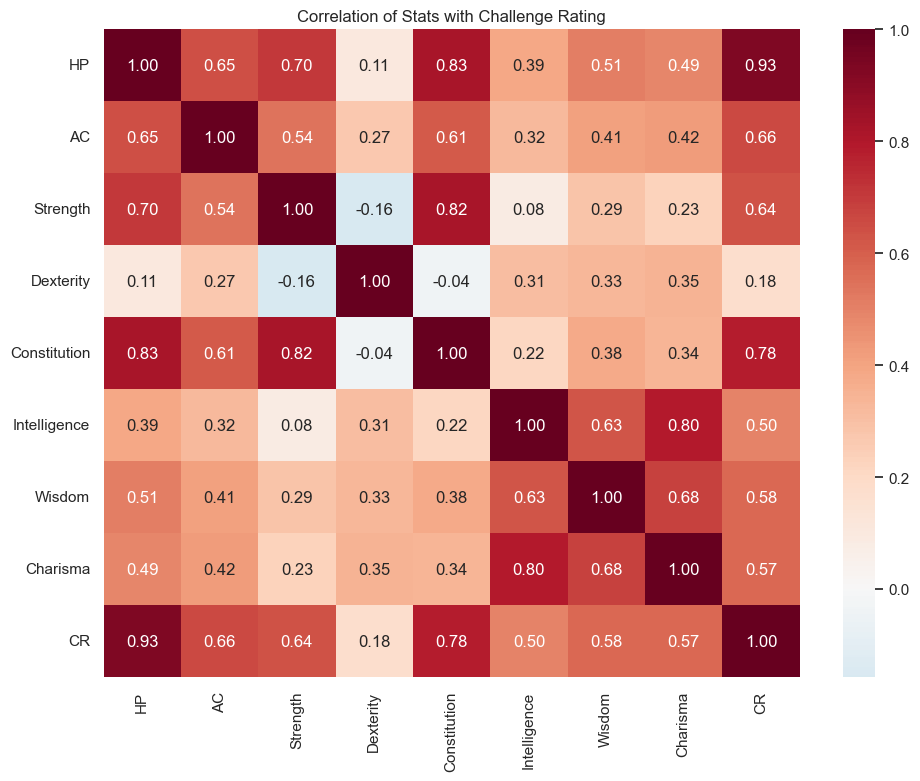

--- Correlation Results (Target: CR) ---
HP: 0.93 (STRONG)
AC: 0.66 (WEAK)
Strength: 0.64 (WEAK)
Dexterity: 0.18 (WEAK)
Constitution: 0.78 (STRONG)
Intelligence: 0.50 (WEAK)
Wisdom: 0.58 (WEAK)
Charisma: 0.57 (WEAK)


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define features
cols = ['HP', 'AC', 'Strength', 'Dexterity', 'Constitution', 
        'Intelligence', 'Wisdom', 'Charisma', 'CR']

# Calculate correlation
corr = prepared_df[cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation of Stats with Challenge Rating')
plt.show()

# Print results for each feature relative to CR
print("--- Correlation Results (Target: CR) ---")
for feature in cols[:-1]: # Exclude CR itself
    coef = corr.loc[feature, 'CR']
    status = "STRONG" if abs(coef) > 0.7 else "WEAK"
    print(f"{feature}: {coef:.2f} ({status})")

This heatmap is the kind of chart I look at when trying to figure out what my model will actually learn.

In this data:
* **HP (0.93)** and **Constitution (0.78)** are the only stats that strongly correlate with CR. That means survivability is the dominant “power signal” in this dataset.
* Stats like **Dexterity (0.18)** and **Intelligence (0.50)** are much weaker predictors. That doesn’t mean they’re wrong — it just means that low-CR and high-CR monsters can both have the same Dexterity.

A red flag here is that HP is almost a straight line with CR. If we build a simple model, it may just learn “HP → CR” and ignore everything else. That could be a problem for weird cases like a high-CR spellcaster with low HP (a “glass cannon”).

### 2.2 Scatter Plots (Linearity Check)
* **HP vs. CR:** We examine if `HP` increases linearly with `CR` or if it scales exponentially at higher tiers (CR 20+).
* **Enhanced Scatter:** We plot `HP` (x-axis) vs. `CR` (y-axis) using `Size` as a color hue. This helps determine if a "Large" monster at a specific CR tier has significantly different health pools than a "Small" monster at the same tier.

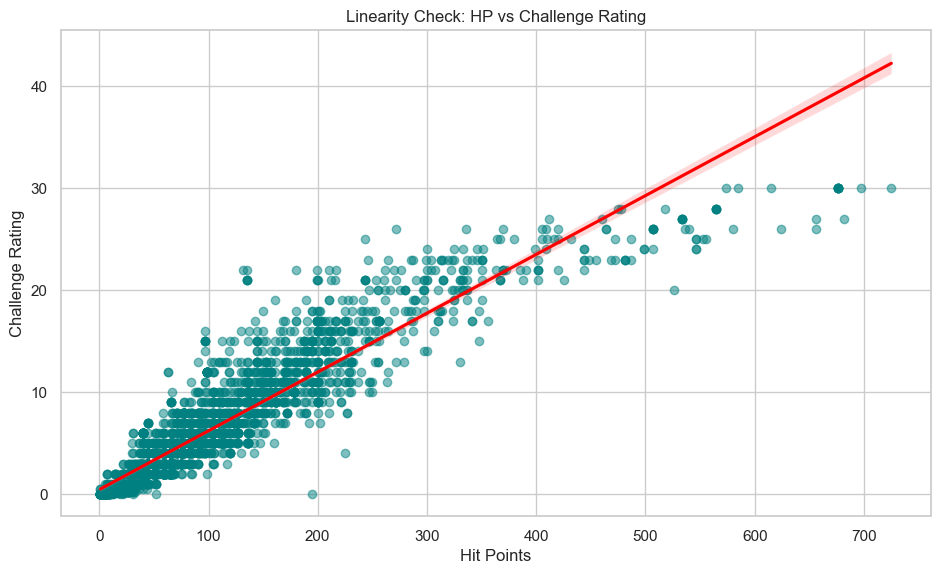

Average HP at CR 0-5: 41.4
Average HP at CR 20+: 392.1
Growth Factor: 9.5x


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot HP vs CR
plt.figure(figsize=(10, 6))
sns.regplot(data=prepared_df, x='HP', y='CR', 
            scatter_kws={'alpha':0.5, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('Linearity Check: HP vs Challenge Rating')
plt.xlabel('Hit Points')
plt.ylabel('Challenge Rating')
plt.show()

# Print growth check
low_cr_avg = prepared_df[prepared_df['CR'] <= 5]['HP'].mean()
high_cr_avg = prepared_df[prepared_df['CR'] >= 20]['HP'].mean()

print(f"Average HP at CR 0-5: {low_cr_avg:.1f}")
print(f"Average HP at CR 20+: {high_cr_avg:.1f}")
print(f"Growth Factor: {high_cr_avg / low_cr_avg:.1f}x")

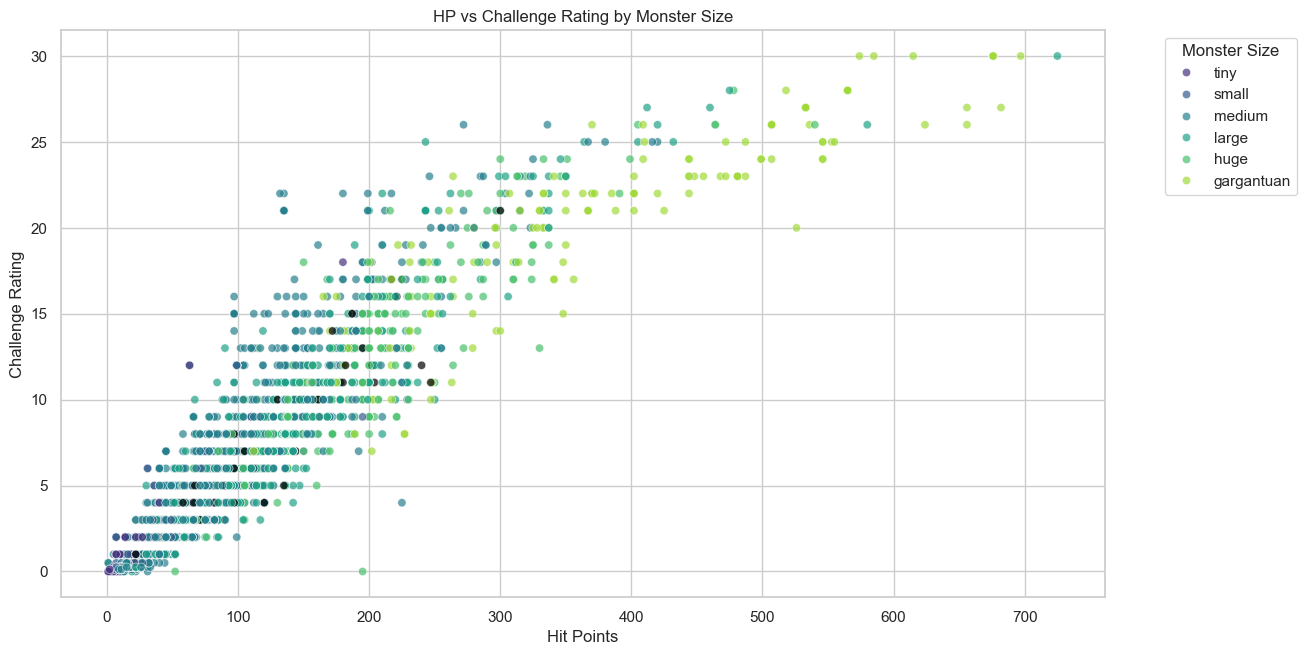

--- Average HP by Size ---
Size
tiny           12.787671
small          27.352313
medium         68.164800
large         109.255814
huge          176.717808
gargantuan    375.548780
Name: HP, dtype: float64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define size order for the legend
size_order = ['tiny', 'small', 'medium', 'large', 'huge', 'gargantuan']

# Plot HP vs CR with Size as hue
plt.figure(figsize=(12, 7))
sns.scatterplot(data=prepared_df, x='HP', y='CR', hue='Size', 
                hue_order=size_order, palette='viridis', alpha=0.7)

plt.title('HP vs Challenge Rating by Monster Size')
plt.xlabel('Hit Points')
plt.ylabel('Challenge Rating')
plt.legend(title='Monster Size', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Print average HP per size category to compare
print("--- Average HP by Size ---")
print(prepared_df.groupby('Size')['HP'].mean().reindex(size_order))

The scatter plots reveal a direct link between monster health and rank. The red trend line stays tight to the data points which proves that Hit Points and Challenge Rating move together in a nearly straight line. HP serves as the primary tool for setting monster difficulty levels.

The growth check numbers show a massive jump in power at higher tiers. Monsters at CR 20 or higher have nearly 10 times the average health of those at CR 5. This growth factor indicates that late game threats rely on massive health pools to challenge players.

The size coded plot shows that physical scale is a major factor. Tiny and Small monsters are almost all clustered in the bottom corner with low HP and low CR. Huge and Gargantuan monsters are the only ones capable of reaching the top tier.

The average HP by size table supports this trend. A Gargantuan monster has nearly 30 times more health than a Tiny one on average. Size acts as a gatekeeper in this data. To reach a high Challenge Rating a monster almost always has to be Huge or Gargantuan.

## Phase 3: Categorical Analysis (The "Why")
**Goal:** Determine if a monster's category (Size or Type) inherently forces it into a higher CR bracket.

### 3.1 Size vs. CR
* **Boxplot Analysis:** We group `CR` by `Size` to test the hypothesis that larger creatures generally occupy higher power tiers.
* **Observation:** We look for "weak" Gargantuan creatures or "powerful" Tiny creatures that may act as outliers to the general rule.

C:\Users\goaar\AppData\Local\Temp\ipykernel_8360\755572781.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=prepared_df, x='Size', y='CR', order=size_order, palette='magma')


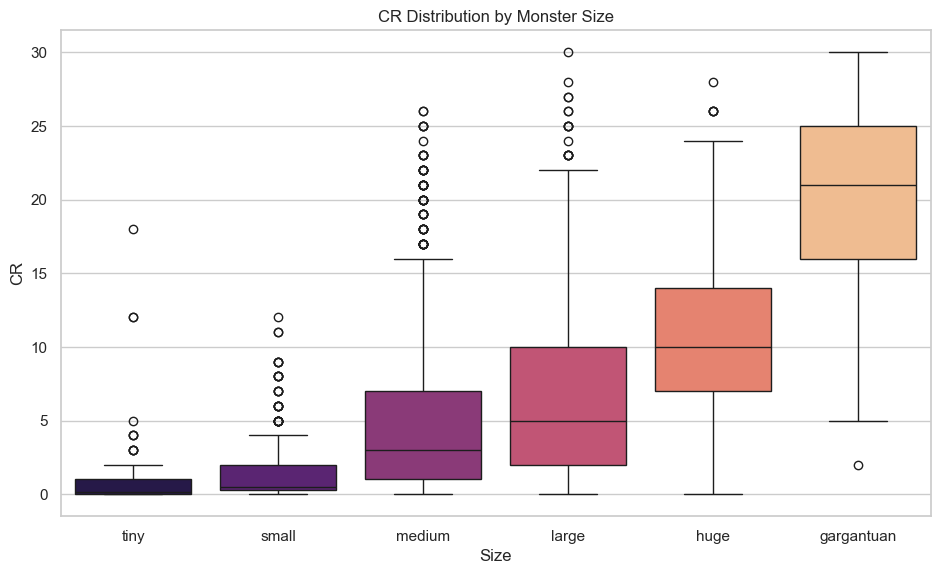

--- CR Statistics by Size ---
                 mean  median   max
Size                               
tiny         0.824486   0.125  18.0
small        1.569395   0.500  12.0
medium       4.642733   3.000  26.0
large        6.677144   5.000  30.0
huge        10.783562  10.000  28.0
gargantuan  20.189024  21.000  30.0

--- Outlier Detection ---
High-CR Tiny Monsters: 3
                       Name    CR
774                demilich  18.0
1921  left hand of manshoon  12.0
3217               traxigor  12.0

Low-CR Gargantuan Monsters: 9
                              Name   CR
1245  gargantuan rug of smothering  2.0
478                      brontodon  5.0
479                   brontosaurus  5.0
1832                       kindori  7.0
3539                     yggdrasti  7.0


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define logical size order
size_order = ['tiny', 'small', 'medium', 'large', 'huge', 'gargantuan']

# Create boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=prepared_df, x='Size', y='CR', order=size_order, palette='magma')
plt.title('CR Distribution by Monster Size')
plt.show()

# Print statistical summary
print("--- CR Statistics by Size ---")
stats = prepared_df.groupby('Size')['CR'].agg(['mean', 'median', 'max']).reindex(size_order)
print(stats)

# Identify outliers
print("\n--- Outlier Detection ---")
powerful_tiny = prepared_df[(prepared_df['Size'] == 'tiny') & (prepared_df['CR'] > 5)]
print(f"High-CR Tiny Monsters: {len(powerful_tiny)}")
if not powerful_tiny.empty:
    print(powerful_tiny[['Name', 'CR']].sort_values(by='CR', ascending=False).head())

weak_gargantuan = prepared_df[(prepared_df['Size'] == 'gargantuan') & (prepared_df['CR'] < 10)]
print(f"\nLow-CR Gargantuan Monsters: {len(weak_gargantuan)}")
if not weak_gargantuan.empty:
    print(weak_gargantuan[['Name', 'CR']].sort_values(by='CR').head())

--- Powerful Tiny Monsters (CR > 5) ---
                       Name    CR    Type
774                demilich  18.0  undead
1921  left hand of manshoon  12.0  undead
3217               traxigor  12.0   beast

--- Weak Gargantuan Monsters (CR < 10) ---
                              Name   CR         Type
1245  gargantuan rug of smothering  2.0    construct
478                      brontodon  5.0        beast
479                   brontosaurus  5.0        beast
1832                       kindori  7.0    celestial
3539                     yggdrasti  7.0        plant
2173              mossback steward  8.0  monstrosity
2928                   sperm whale  8.0        beast
1608          horizonback tortoise  8.0  monstrosity
553                       ceratops  9.0  monstrosity


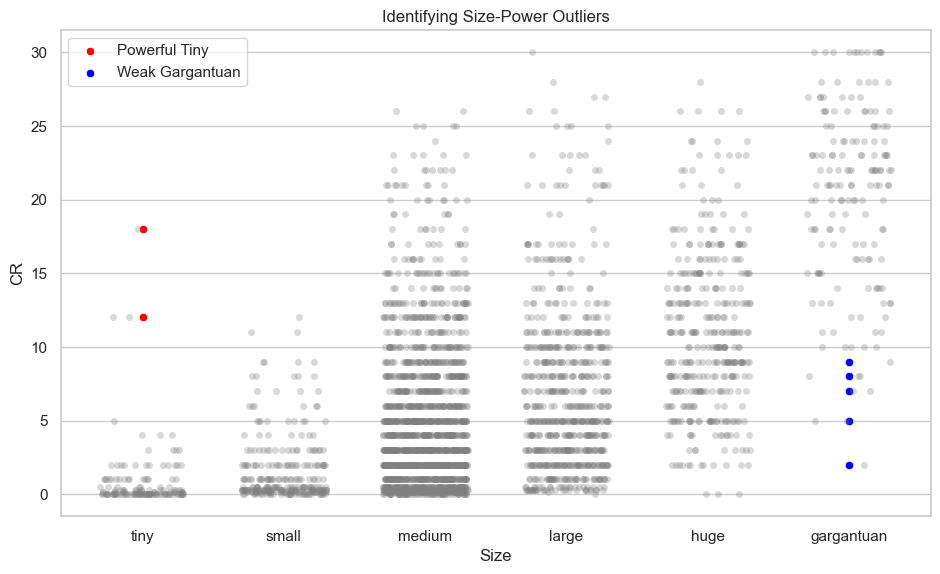

In [15]:
# Identify outliers at the extremes of size
print("--- Powerful Tiny Monsters (CR > 5) ---")
high_power_tiny = prepared_df[(prepared_df['Size'] == 'tiny') & (prepared_df['CR'] > 5)]
print(high_power_tiny[['Name', 'CR', 'Type']].sort_values(by='CR', ascending=False))

print("\n--- Weak Gargantuan Monsters (CR < 10) ---")
low_power_gargantuan = prepared_df[(prepared_df['Size'] == 'gargantuan') & (prepared_df['CR'] < 10)]
print(low_power_gargantuan[['Name', 'CR', 'Type']].sort_values(by='CR'))

# Visualization of these outliers
plt.figure(figsize=(10, 6))
sns.stripplot(data=prepared_df, x='Size', y='CR', order=size_order, jitter=0.3, alpha=0.3, color='gray')
sns.scatterplot(data=high_power_tiny, x='Size', y='CR', color='red', label='Powerful Tiny')
sns.scatterplot(data=low_power_gargantuan, x='Size', y='CR', color='blue', label='Weak Gargantuan')
plt.title('Identifying Size-Power Outliers')
plt.legend()
plt.show()

The boxplot analysis confirms that monster size and power level are closely linked. As size increases from Tiny to Gargantuan, the average Challenge Rating rises steadily. Tiny creatures stay near the bottom of the scale with a median CR close to zero. Gargantuan creatures represent a massive jump in power with a median CR of 21.

The outlier detection identifies rare exceptions to this rule. A few Tiny monsters like the Demilich reach very high CR levels despite their size. These outliers suggest that high intelligence or magical abilities can override the usual physical limits of a small body.

Low-power Gargantuan monsters also exist but are less common. Creatures like the Brontosaurus have high health but low CR because they lack dangerous attacks or high armor. This confirms that while size usually dictates a monster's potential, specific abilities or lack of defenses can push a creature far away from its expected power tier.

### 3.2 Type vs. CR
* **Mean CR per Type:** We calculate the average `CR` for each monster `Type` using a bar chart.
* **Comparison:** We compare high-fantasy archetypes (e.g., "Dragons") against baseline creatures (e.g., "Beasts") to see if `Type` is a statistically significant feature.

C:\Users\goaar\AppData\Local\Temp\ipykernel_8360\2741304524.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_cr.values, y=type_cr.index, palette='coolwarm')


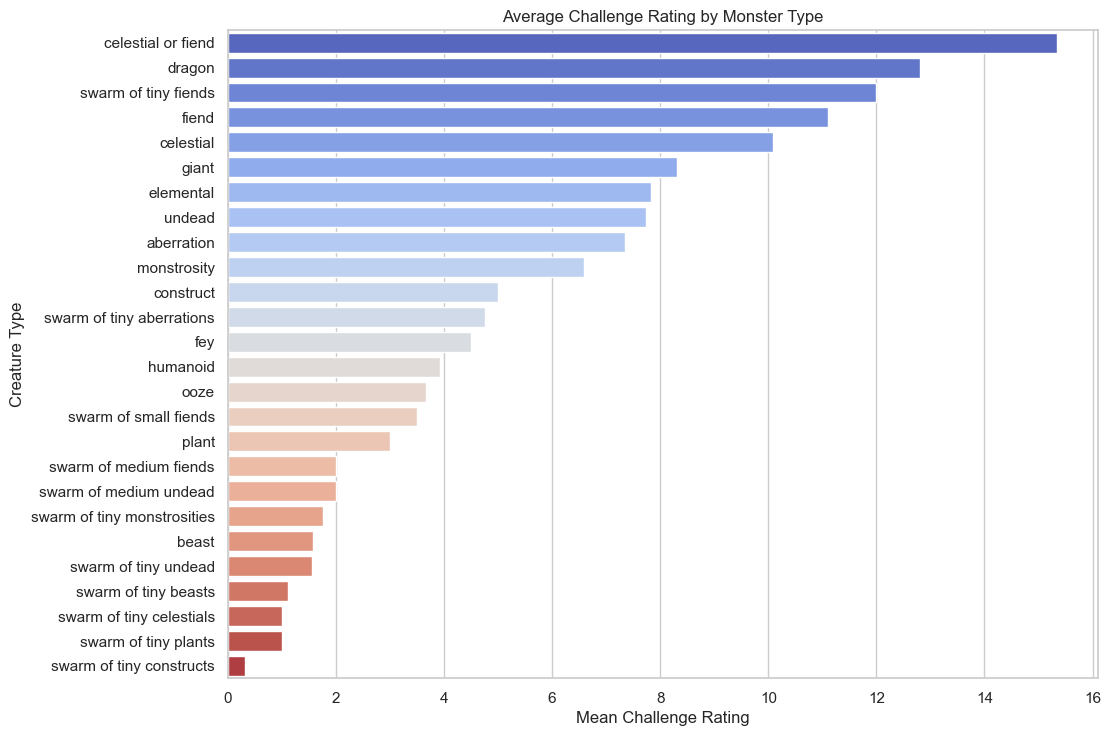

Mean CR by Type:
Type
celestial or fiend             15.333333
dragon                         12.801702
swarm of tiny fiends           12.000000
fiend                          11.095620
celestial                      10.079670
giant                           8.313665
elemental                       7.824786
undead                          7.743421
aberration                      7.353737
monstrosity                     6.584350
construct                       5.005682
swarm of tiny aberrations       4.750000
fey                             4.495652
humanoid                        3.933043
ooze                            3.664062
swarm of small fiends           3.500000
plant                           3.000000
swarm of medium fiends          2.000000
swarm of medium undead          2.000000
swarm of tiny monstrosities     1.750000
beast                           1.581845
swarm of tiny undead            1.562500
swarm of tiny beasts            1.109375
swarm of tiny celestials        1.0

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean CR for each type and sort
type_cr = prepared_df.groupby('Type')['CR'].mean().sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(10, 8))
sns.barplot(x=type_cr.values, y=type_cr.index, palette='coolwarm')
plt.title('Average Challenge Rating by Monster Type')
plt.xlabel('Mean Challenge Rating')
plt.ylabel('Creature Type')
plt.show()

# Print results
print("Mean CR by Type:")
print(type_cr)

C:\Users\goaar\AppData\Local\Temp\ipykernel_8360\1882906867.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=prepared_df, x='CR', y='Type', order=all_types.index, palette='vlag')


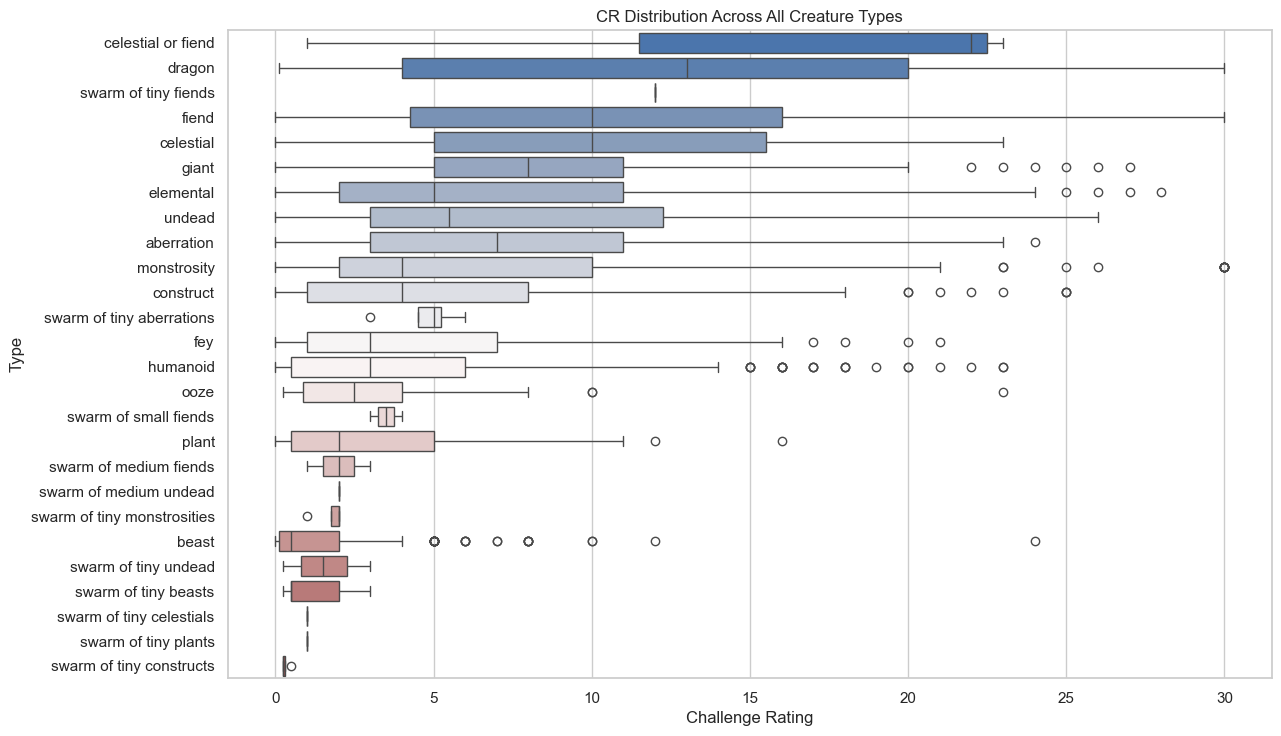

--- Full Type Comparison (Sorted by Power) ---
                                  mean  count
Type                                         
celestial or fiend           15.333333      3
dragon                       12.801702    191
swarm of tiny fiends         12.000000      1
fiend                        11.095620    234
celestial                    10.079670     91
giant                         8.313665    161
elemental                     7.824786    117
undead                        7.743421    304
aberration                    7.353737    194
monstrosity                   6.584350    369
construct                     5.005682    264
swarm of tiny aberrations     4.750000      4
fey                           4.495652    115
humanoid                      3.933043   1206
ooze                          3.664062     32
swarm of small fiends         3.500000      2
plant                         3.000000     85
swarm of medium fiends        2.000000      2
swarm of medium undead        2.0

In [17]:
# Get all unique types and calculate mean CR
all_types = prepared_df.groupby('Type')['CR'].agg(['mean', 'count']).sort_values('mean', ascending=False)

# Plotting the full distribution
plt.figure(figsize=(12, 8))
sns.boxplot(data=prepared_df, x='CR', y='Type', order=all_types.index, palette='vlag')
plt.title('CR Distribution Across All Creature Types')
plt.xlabel('Challenge Rating')
plt.show()

# Print the full list for comparison
print("--- Full Type Comparison (Sorted by Power) ---")
print(all_types)

# Comparison logic: Top vs Bottom
top_type = all_types.index[0]
bottom_type = all_types.index[-1]
gap = all_types.loc[top_type, 'mean'] / all_types.loc[bottom_type, 'mean']

print(f"\nMost powerful type: {top_type} (Mean CR: {all_types.loc[top_type, 'mean']:.2f})")
print(f"Least powerful type: {bottom_type} (Mean CR: {all_types.loc[bottom_type, 'mean']:.2f})")
print(f"Power gap: {gap:.1f}x difference in average CR.")

C:\Users\goaar\AppData\Local\Temp\ipykernel_8360\4170661284.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_ranks.values, y=type_ranks.index, palette='mako')


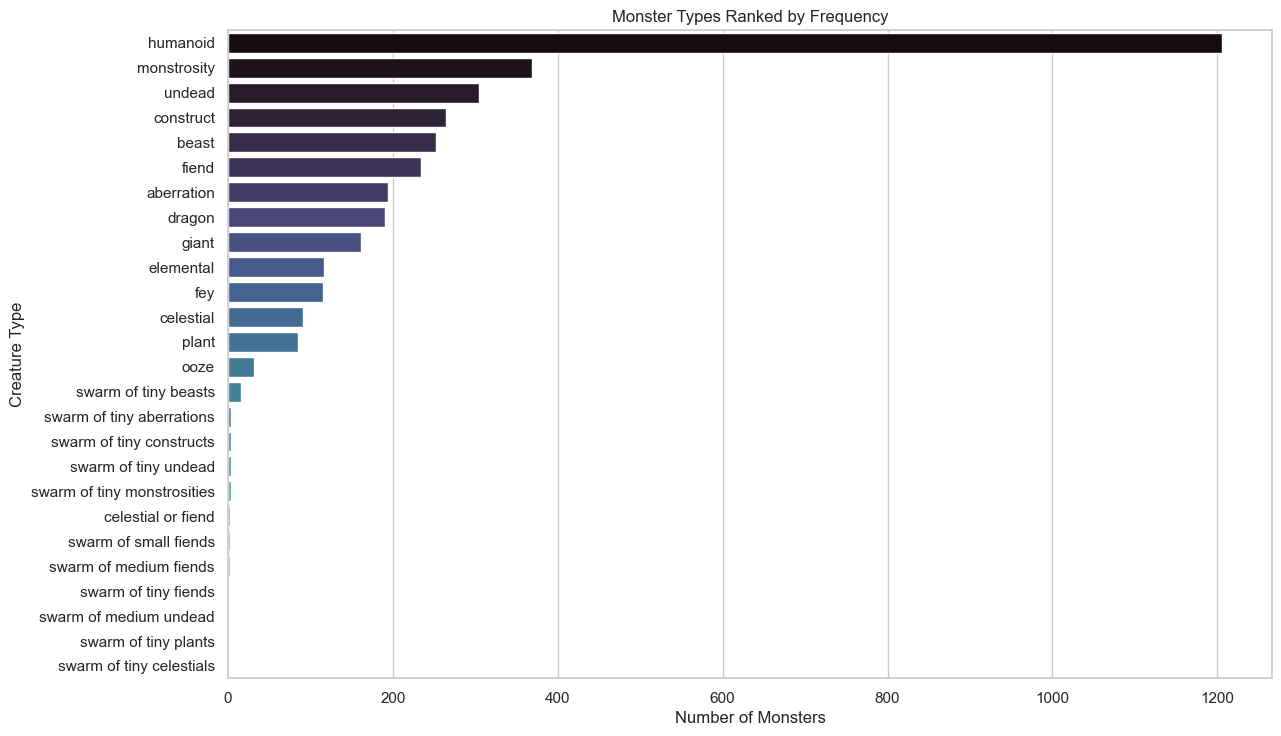

--- Monster Types Ranked by Count ---
Type
humanoid                       1206
monstrosity                     369
undead                          304
construct                       264
beast                           252
fiend                           234
aberration                      194
dragon                          191
giant                           161
elemental                       117
fey                             115
celestial                        91
plant                            85
ooze                             32
swarm of tiny beasts             16
swarm of tiny aberrations         4
swarm of tiny constructs          4
swarm of tiny undead              4
swarm of tiny monstrosities       4
celestial or fiend                3
swarm of small fiends             2
swarm of medium fiends            2
swarm of tiny fiends              1
swarm of medium undead            1
swarm of tiny plants              1
swarm of tiny celestials          1
Name: count, dtype: i

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate counts for each type and sort from high to low
type_ranks = prepared_df['Type'].value_counts()

# Plot the distribution
plt.figure(figsize=(12, 8))
sns.barplot(x=type_ranks.values, y=type_ranks.index, palette='mako')
plt.title('Monster Types Ranked by Frequency')
plt.xlabel('Number of Monsters')
plt.ylabel('Creature Type')
plt.show()

# Print the ranked results
print("--- Monster Types Ranked by Count ---")
print(type_ranks)

The full distribution results show a massive power hierarchy based on creature type. Celestial-fiend hybrids and dragons sit at the top of the range. Swarms and tiny constructs occupy the very bottom. These rankings demonstrate that specific labels are strong indicators of a monster's role in the game.

The gap between the highest and lowest tiers is extreme. The average Challenge Rating for the most powerful group is over 49 times higher than the average for a swarm of tiny constructs. This power gap highlights that type is a major predictor for the ranking system.

Many types like fiends and celestials show a wide spread of power levels in the boxplot. This means they appear at various stages of gameplay. Other types like beasts or swarms are tightly packed at the lower end of the scale. These results confirm that including the full variety of types provides critical information for distinguishing between weak encounters and epic bosses.

## Summary 

---

The bestiary dataset is heavily skewed toward low power levels. Most monsters cluster between Challenge Rating 0 and 5 while legendary threats are rare. Defensive stats show two different patterns. Armor Class is restricted to a narrow range making every single point highly valuable. Hit Points are unbounded and scale dramatically reaching over 700 for top tier bosses. Physical attributes like Strength and Constitution show more variety and higher averages than mental stats. This makes them better predictors of monster power.

Categorical data shows that Medium is the standard size for most creatures. Humanoids and monstrosities make up the bulk of the population. There is a clear hierarchy where size and type dictate potential. Larger monsters almost always have higher ranks. Dragons and celestials sit at the top of the power scale while beasts and swarms remain at the bottom. Rare outliers like high power tiny creatures suggest that magical traits can sometimes override physical size.

Correlation analysis confirms that survivability is the main driver of Challenge Rating. Hit Points and Constitution move in close sync with rank. Other stats like Dexterity and Wisdom remain consistent across all power levels and offer less predictive value. The strong linear relationship between health and rank proves that Hit Points are the primary tool used to scale game difficulty. This suggests the model should focus on health and physical size to accurately estimate monster strength.